# 🌿 Plant Disease Detection using MobileNetV2 (PyTorch)
### MSc Data Analytics — Computer Vision and Artificial Intelligence
**Dataset:** PlantVillage (via TensorFlow Datasets)  
**Framework:** PyTorch  
**Model:** MobileNetV2 (Transfer Learning with Fine-Tuning)

## Cell 1 — Install & Import Dependencies

In [1]:
#  Install required packages
!pip install tensorflow-datasets torch torchvision scikit-learn matplotlib seaborn --quiet

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights

import tensorflow_datasets as tfds
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

#  Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## Cell 2 — Load PlantVillage Dataset via TensorFlow Datasets

In [2]:
# Load PlantVillage from TensorFlow Datasets
# Source: https://www.tensorflow.org/datasets/catalog/plant_village
# The dataset contains 54,306 images of 38 plant disease classes

print('Downloading PlantVillage dataset...')
ds_info = tfds.load(
    'plant_village',
    split='train',
    with_info=True,
    as_supervised=True
)
ds_full, info = ds_info

NUM_CLASSES = info.features['label'].num_classes
CLASS_NAMES = info.features['label'].names
TOTAL_IMAGES = info.splits['train'].num_examples

print(f'\nDataset loaded successfully!')
print(f'Total images     : {TOTAL_IMAGES:,}')
print(f'Number of classes: {NUM_CLASSES}')
print(f'\nAll {NUM_CLASSES} disease classes:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  [{i:02d}] {name}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.B0AVSN_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.

Dataset loaded successfully!
Total images     : 54,303
Number of classes: 38

All 38 disease classes:
  [00] Apple___Apple_scab
  [01] Apple___Black_rot
  [02] Apple___Cedar_apple_rust
  [03] Apple___healthy
  [04] Blueberry___healthy
  [05] Cherry___healthy
  [06] Cherry___Powdery_mildew
  [07] Corn___Cercospora_leaf_spot Gray_leaf_spot
  [08] Corn___Common_rust
  [09] Corn___healthy
  [10] Corn___Northern_Leaf_Blight
  [11] Grape___Black_rot
  [12] Grape___Esca_(Black_Measles)
  [13] Grape___healthy
  [14] Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  [15] Orange___Haunglongbing_(Citrus_greening)
  [16] Peach___Bacterial_spot
  [17] Peach___healthy
  [18] Pepper,_bell___Bacterial_spot
  [19] Pepper,_bell___healthy
  [20] Potato___Early_blight
  [21] Potato___healthy
  [22] Potato___Late_blight
  [23] Raspberry___healthy
  [24] Soybean___healthy
  [25]

## Cell 3 — Visualise Sample Images per Class

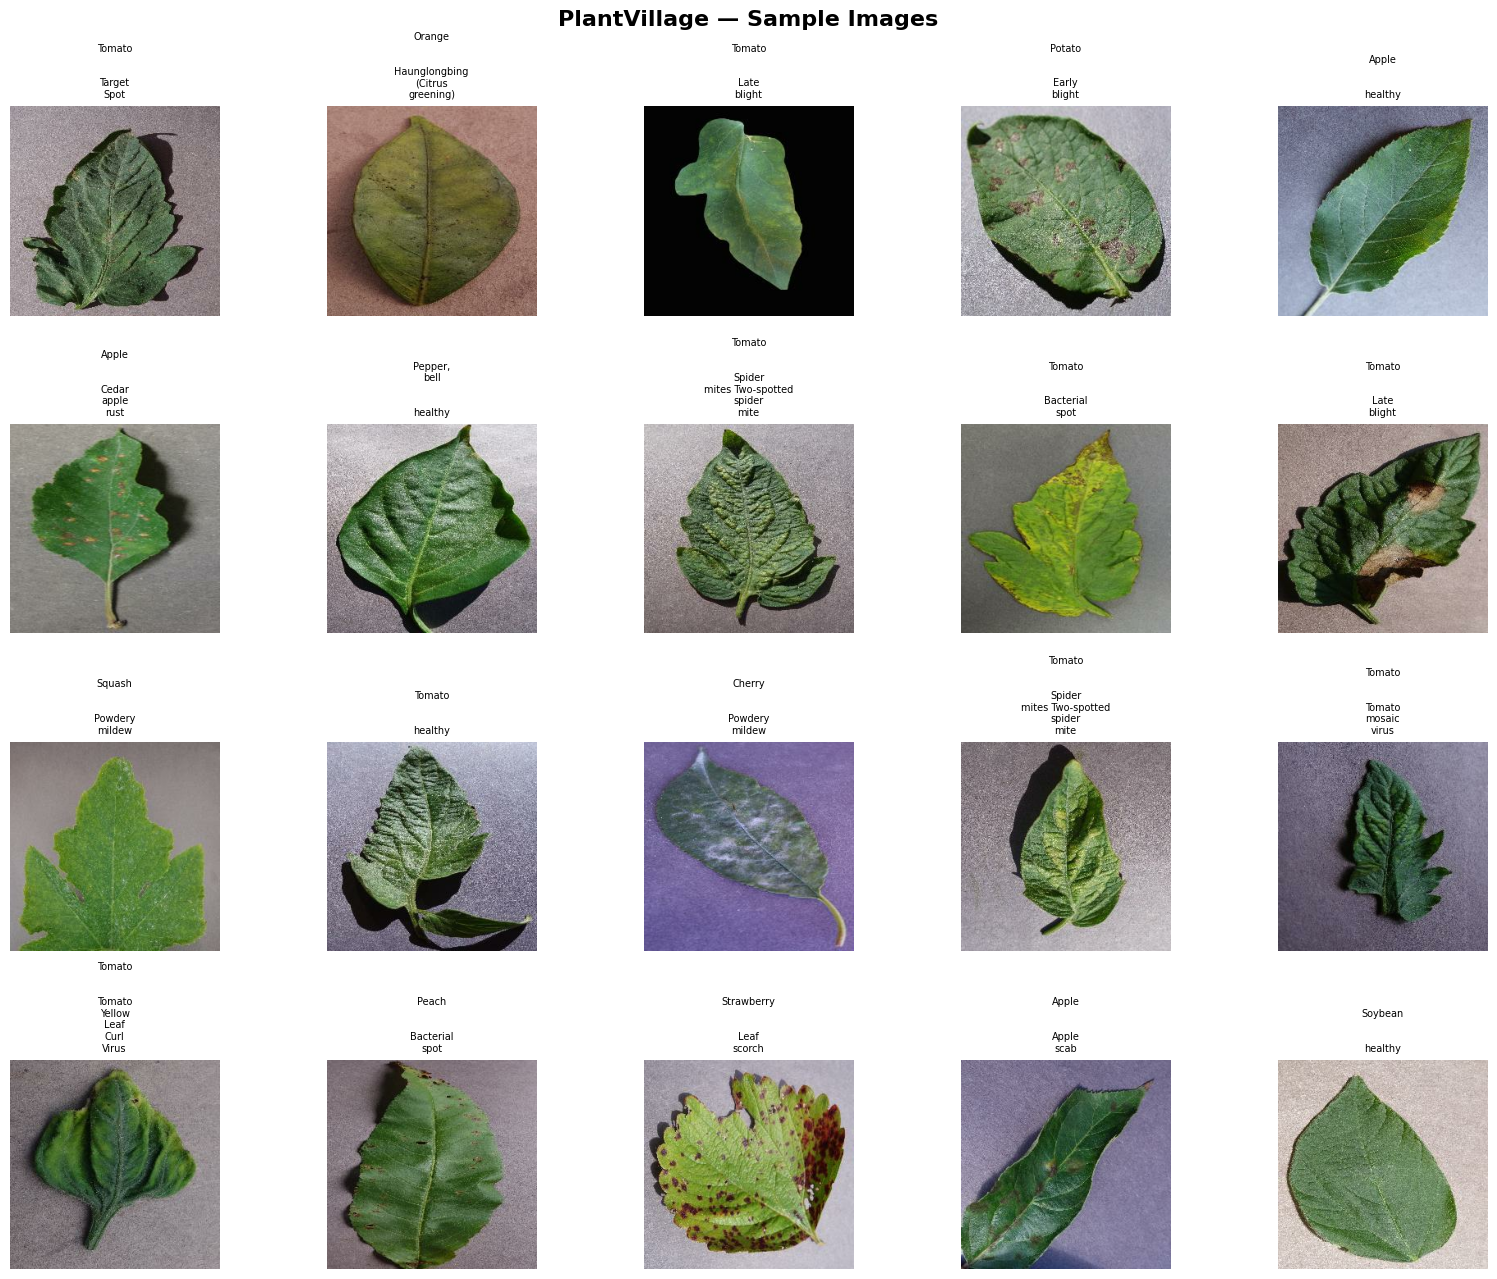

Sample image grid saved.


In [3]:
#  Visualise a sample of images from the dataset
import tensorflow as tf

sample_ds = ds_full.take(20)
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('PlantVillage — Sample Images', fontsize=16, fontweight='bold')

for ax, (image, label) in zip(axes.flatten(), sample_ds):
    img_np = image.numpy().astype('uint8')
    ax.imshow(img_np)
    short_name = CLASS_NAMES[label.numpy()].replace('_', '\n')
    ax.set_title(short_name, fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample image grid saved.')

## Cell 4 — Class Distribution Bar Chart

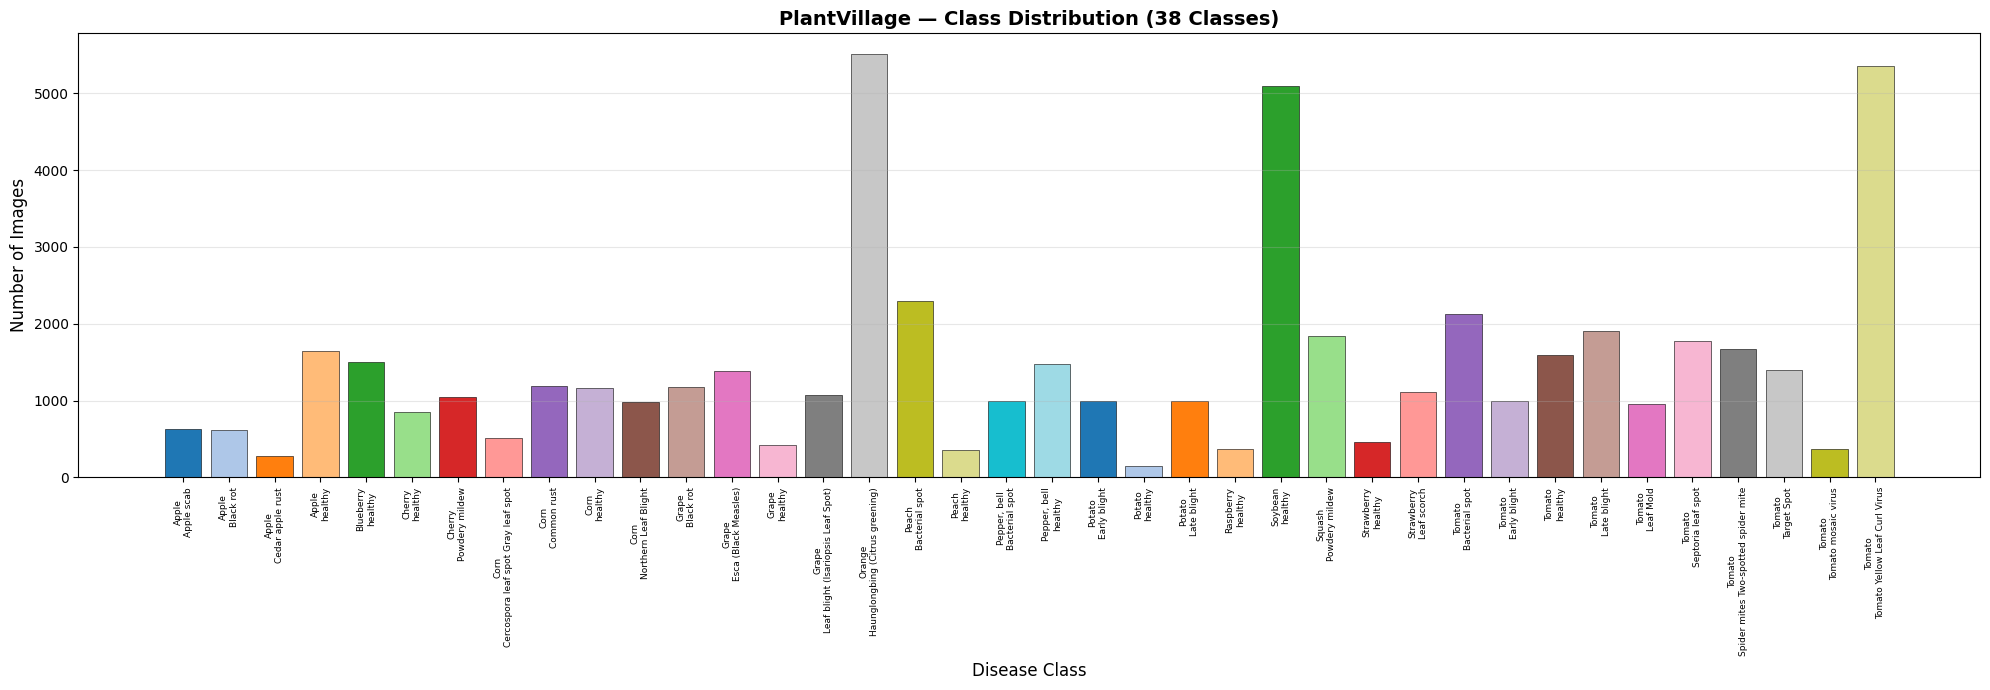

Total images confirmed: 54,303


In [4]:
#  Class distribution across all 38 classes
label_counts = np.zeros(NUM_CLASSES, dtype=int)

for _, label in ds_full:
    label_counts[label.numpy()] += 1

short_labels = [n.replace('___', '\n').replace('_', ' ') for n in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(20, 7))
bars = ax.bar(range(NUM_CLASSES), label_counts,
              color=plt.cm.tab20.colors * 2, edgecolor='black', linewidth=0.4)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(short_labels, rotation=90, fontsize=6.5)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_xlabel('Disease Class', fontsize=12)
ax.set_title('PlantVillage — Class Distribution (38 Classes)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total images confirmed: {label_counts.sum():,}')

## Cell 5 — Convert TF Dataset → NumPy Arrays

In [5]:
# Convert TensorFlow dataset to NumPy for PyTorch compatibility
# We work with a 10-class subset for faster training on Colab free GPU
# Subset: first 10 classes (diverse mix of crops and diseases)

SUBSET_CLASSES = 10   # change to NUM_CLASSES for full training
MAX_PER_CLASS  = 800  # images per class (keeps training manageable)
IMG_SIZE       = 224  # MobileNetV2 input size

subset_class_names = CLASS_NAMES[:SUBSET_CLASSES]
print(f'Using {SUBSET_CLASSES} classes:')
for i, n in enumerate(subset_class_names):
    print(f'  [{i}] {n}')

images_list, labels_list = [], []
class_counters = np.zeros(SUBSET_CLASSES, dtype=int)

for img_tf, lbl_tf in ds_full:
    lbl = lbl_tf.numpy()
    if lbl >= SUBSET_CLASSES:
        continue
    if class_counters[lbl] >= MAX_PER_CLASS:
        continue
    img_np = img_tf.numpy().astype('uint8')
    images_list.append(img_np)
    labels_list.append(lbl)
    class_counters[lbl] += 1
    if class_counters.min() >= MAX_PER_CLASS:
        break

print(f'\nImages collected per class: {class_counters}')
print(f'Total images in subset    : {len(images_list):,}')

Using 10 classes:
  [0] Apple___Apple_scab
  [1] Apple___Black_rot
  [2] Apple___Cedar_apple_rust
  [3] Apple___healthy
  [4] Blueberry___healthy
  [5] Cherry___healthy
  [6] Cherry___Powdery_mildew
  [7] Corn___Cercospora_leaf_spot Gray_leaf_spot
  [8] Corn___Common_rust
  [9] Corn___healthy

Images collected per class: [630 621 275 800 800 800 800 513 800 800]
Total images in subset    : 6,839


## Cell 6 — PyTorch Custom Dataset + Data Augmentation Transforms

In [6]:
#  Custom PyTorch Dataset
# images_list contains NumPy uint8 arrays; labels_list contains int labels.
# We store everything as plain Python lists and convert to PIL inside __getitem__.

class PlantDiseaseDataset(Dataset):
    """
    Custom PyTorch Dataset that wraps NumPy image arrays.
    Each item is converted to PIL and transformed on-the-fly.
    """
    def __init__(self, images, labels, transform=None):
        # Store as list of NumPy arrays (uint8, HxWxC)
        self.images    = [np.array(img, dtype=np.uint8) for img in images]
        self.labels    = [int(l) for l in labels]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Always convert NumPy → PIL here (guaranteed safe)
        img   = Image.fromarray(self.images[idx])   # uint8 NumPy → PIL RGB
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


#  ImageNet mean/std for MobileNetV2 normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=20),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Transforms defined successfully.')
print('Train transform pipeline:')
for t in train_transform.transforms:
    print(f'  → {t}')
print('\nVal/Test transform pipeline:')
for t in val_transform.transforms:
    print(f'  → {t}')

Transforms defined successfully.
Train transform pipeline:
  → Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  → RandomHorizontalFlip(p=0.5)
  → RandomVerticalFlip(p=0.3)
  → ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
  → RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
  → ToTensor()
  → Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Val/Test transform pipeline:
  → Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  → ToTensor()
  → Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


## Cell 7 — Train / Validation / Test Split & DataLoaders

In [7]:
#  Manual index-based split — avoids TransformSubset complexity entirely
# This approach splits the raw index list first, then builds 3 separate
# PlantDiseaseDataset objects each with the correct transform.

import random as _random

total  = len(images_list)
indices = list(range(total))
_random.seed(42)
_random.shuffle(indices)

train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_idx = indices[:train_size]
val_idx   = indices[train_size : train_size + val_size]
test_idx  = indices[train_size + val_size :]

# Build 3 datasets — each holds its own copy of NumPy arrays + correct transform
train_dataset = PlantDiseaseDataset(
    [images_list[i] for i in train_idx],
    [labels_list[i] for i in train_idx],
    transform=train_transform
)
val_dataset = PlantDiseaseDataset(
    [images_list[i] for i in val_idx],
    [labels_list[i] for i in val_idx],
    transform=val_transform
)
test_dataset = PlantDiseaseDataset(
    [images_list[i] for i in test_idx],
    [labels_list[i] for i in test_idx],
    transform=val_transform
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Dataset split (70 / 15 / 15):')
print(f'  Train  : {train_size:,} images  ({train_size/total*100:.1f}%)')
print(f'  Val    : {val_size:,} images  ({val_size/total*100:.1f}%)')
print(f'  Test   : {test_size:,} images  ({test_size/total*100:.1f}%)')
print(f'  Total  : {total:,} images')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Train batches : {len(train_loader)}')

# Quick sanity check — fetch one batch to confirm no errors
imgs_check, lbls_check = next(iter(train_loader))
print(f'\nSanity check — batch shape : {imgs_check.shape}')
print(f'Sanity check — label dtype : {lbls_check.dtype}')
print('DataLoaders ready!')

Dataset split (70 / 15 / 15):
  Train  : 4,787 images  (70.0%)
  Val    : 1,025 images  (15.0%)
  Test   : 1,027 images  (15.0%)
  Total  : 6,839 images
  Batch size    : 32
  Train batches : 150

Sanity check — batch shape : torch.Size([32, 3, 224, 224])
Sanity check — label dtype : torch.int64
DataLoaders ready!


## Cell 8 — MobileNetV2 Model Architecture (Transfer Learning)

In [8]:
# Build MobileNetV2 with custom classification head
# Strategy: Freeze all backbone layers → train custom head → unfreeze top layers

def build_mobilenetv2(num_classes, freeze_backbone=True):
    """
    Loads ImageNet-pretrained MobileNetV2 and replaces the
    default classifier with a custom head for `num_classes`.
    """
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


model = build_mobilenetv2(num_classes=SUBSET_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('═' * 55)
print('       MobileNetV2 — Transfer Learning Summary')
print('═' * 55)
print(f'  Total parameters     : {total_params:>12,}')
print(f'  Trainable parameters : {trainable_params:>12,}')
print(f'  Frozen parameters    : {frozen_params:>12,}')
print('═' * 55)
print(f'  Input size           : 3 × {IMG_SIZE} × {IMG_SIZE}')
print(f'  Output classes       : {SUBSET_CLASSES}')
print(f'  Backbone             : MobileNetV2 (ImageNet pretrained)')
print(f'  Custom head          : Dropout → Linear(1280→512) → ReLU → BN → Dropout → Linear(512→{SUBSET_CLASSES})')
print('═' * 55)

# Print model structure
print('\nClassifier head:')
print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 124MB/s]

═══════════════════════════════════════════════════════
       MobileNetV2 — Transfer Learning Summary
═══════════════════════════════════════════════════════
  Total parameters     :    2,885,898
  Trainable parameters :      662,026
  Frozen parameters    :    2,223,872
═══════════════════════════════════════════════════════
  Input size           : 3 × 224 × 224
  Output classes       : 10
  Backbone             : MobileNetV2 (ImageNet pretrained)
  Custom head          : Dropout → Linear(1280→512) → ReLU → BN → Dropout → Linear(512→10)
═══════════════════════════════════════════════════════

Classifier head:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): ReLU()
  (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=512, out_features=10, bias=True)
)


## Cell 9 — Loss Function, Optimizer & Learning Rate Scheduler

In [9]:
#  Training configuration
EPOCHS_PHASE1 = 8    # Train head only (backbone frozen)
EPOCHS_PHASE2 = 7    # Fine-tune top backbone layers
LR_PHASE1     = 1e-3
LR_PHASE2     = 5e-5

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Phase 1: only classifier parameters
optimizer_phase1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=1e-4
)
scheduler_phase1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_phase1, T_max=EPOCHS_PHASE1, eta_min=1e-6
)

print('Training configuration:')
print(f'  Loss function : CrossEntropyLoss (label_smoothing=0.1)')
print(f'  Optimizer     : Adam')
print(f'  Scheduler     : CosineAnnealingLR')
print(f'  Phase 1 LR    : {LR_PHASE1}  ({EPOCHS_PHASE1} epochs, frozen backbone)')
print(f'  Phase 2 LR    : {LR_PHASE2}  ({EPOCHS_PHASE2} epochs, fine-tuning)')

Training configuration:
  Loss function : CrossEntropyLoss (label_smoothing=0.1)
  Optimizer     : Adam
  Scheduler     : CosineAnnealingLR
  Phase 1 LR    : 0.001  (8 epochs, frozen backbone)
  Phase 2 LR    : 5e-05  (7 epochs, fine-tuning)


## Cell 10 — Training & Validation Loop Functions

In [10]:
# Training helper functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over training data."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds        = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on validation/test set."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, correct / total


print('Training and evaluation functions defined successfully.')

Training and evaluation functions defined successfully.


## Cell 11 — Phase 1 Training (Frozen Backbone)

In [11]:
# Phase 1: Train classifier head only
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_acc  = 0.0
best_model_wts = None

print('Phase 1 — Training classifier head (backbone frozen)')
print('─' * 65)
print(f'{"Epoch":<8}{"Train Loss":<14}{"Train Acc":<14}{"Val Loss":<14}{"Val Acc":<12}{"LR"}')
print('─' * 65)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion,
                                       optimizer_phase1, DEVICE)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler_phase1.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    cur_lr = optimizer_phase1.param_groups[0]['lr']
    print(f'{epoch:<8}{tr_loss:<14.4f}{tr_acc*100:<14.2f}{vl_loss:<14.4f}{vl_acc*100:<12.2f}{cur_lr:.2e}')

    if vl_acc > best_val_acc:
        best_val_acc  = vl_acc
        import copy
        best_model_wts = copy.deepcopy(model.state_dict())

print('─' * 65)
print(f'Phase 1 complete. Best Val Accuracy: {best_val_acc*100:.2f}%')

Phase 1 — Training classifier head (backbone frozen)
─────────────────────────────────────────────────────────────────
Epoch   Train Loss    Train Acc     Val Loss      Val Acc     LR
─────────────────────────────────────────────────────────────────
1       0.8524        88.45         0.6392        98.44       9.62e-04
2       0.7339        94.07         0.6250        98.44       8.54e-04
3       0.7133        94.99         0.6201        98.05       6.92e-04
4       0.6996        95.24         0.6146        98.93       5.01e-04
5       0.6923        95.36         0.6067        98.44       3.09e-04
6       0.6810        95.72         0.5958        99.02       1.47e-04
7       0.6810        95.93         0.5923        98.93       3.90e-05
8       0.6716        96.14         0.5944        99.22       1.00e-06
─────────────────────────────────────────────────────────────────
Phase 1 complete. Best Val Accuracy: 99.22%


## Cell 12 — Phase 2 Fine-Tuning (Unfreeze Top Backbone Layers)

In [12]:
# Phase 2: Unfreeze last 5 feature blocks for fine-tuning
# MobileNetV2 features has 19 blocks (indices 0-18)
UNFREEZE_FROM = 14   # unfreeze blocks 14-18

for i, layer in enumerate(model.features):
    if i >= UNFREEZE_FROM:
        for param in layer.parameters():
            param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 trainable parameters: {trainable_p2:,}')

optimizer_phase2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2, weight_decay=1e-4
)
scheduler_phase2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_phase2, T_max=EPOCHS_PHASE2, eta_min=1e-7
)

print('\nPhase 2 — Fine-tuning (last 5 backbone blocks + classifier)')
print('─' * 65)
print(f'{"Epoch":<8}{"Train Loss":<14}{"Train Acc":<14}{"Val Loss":<14}{"Val Acc":<12}{"LR"}')
print('─' * 65)

for epoch in range(EPOCHS_PHASE1 + 1, EPOCHS_PHASE1 + EPOCHS_PHASE2 + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion,
                                       optimizer_phase2, DEVICE)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler_phase2.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    cur_lr = optimizer_phase2.param_groups[0]['lr']
    print(f'{epoch:<8}{tr_loss:<14.4f}{tr_acc*100:<14.2f}{vl_loss:<14.4f}{vl_acc*100:<12.2f}{cur_lr:.2e}')

    if vl_acc > best_val_acc:
        best_val_acc  = vl_acc
        best_model_wts = copy.deepcopy(model.state_dict())

print('─' * 65)
print(f'Phase 2 complete. Best Val Accuracy: {best_val_acc*100:.2f}%')

# Restore best weights
model.load_state_dict(best_model_wts)
print('Best model weights restored.')

Phase 2 trainable parameters: 2,343,370

Phase 2 — Fine-tuning (last 5 backbone blocks + classifier)
─────────────────────────────────────────────────────────────────
Epoch   Train Loss    Train Acc     Val Loss      Val Acc     LR
─────────────────────────────────────────────────────────────────
9       0.6411        97.24         0.5740        99.41       4.75e-05
10      0.6146        98.27         0.5613        99.71       4.06e-05
11      0.6015        98.54         0.5538        99.71       3.06e-05
12      0.5834        99.23         0.5495        99.61       1.95e-05
13      0.5809        99.27         0.5472        99.71       9.49e-06
14      0.5756        99.31         0.5439        99.61       2.57e-06
15      0.5722        99.54         0.5427        99.61       1.00e-07
─────────────────────────────────────────────────────────────────
Phase 2 complete. Best Val Accuracy: 99.71%
Best model weights restored.


## Cell 13 — Training History Plots (Loss & Accuracy)

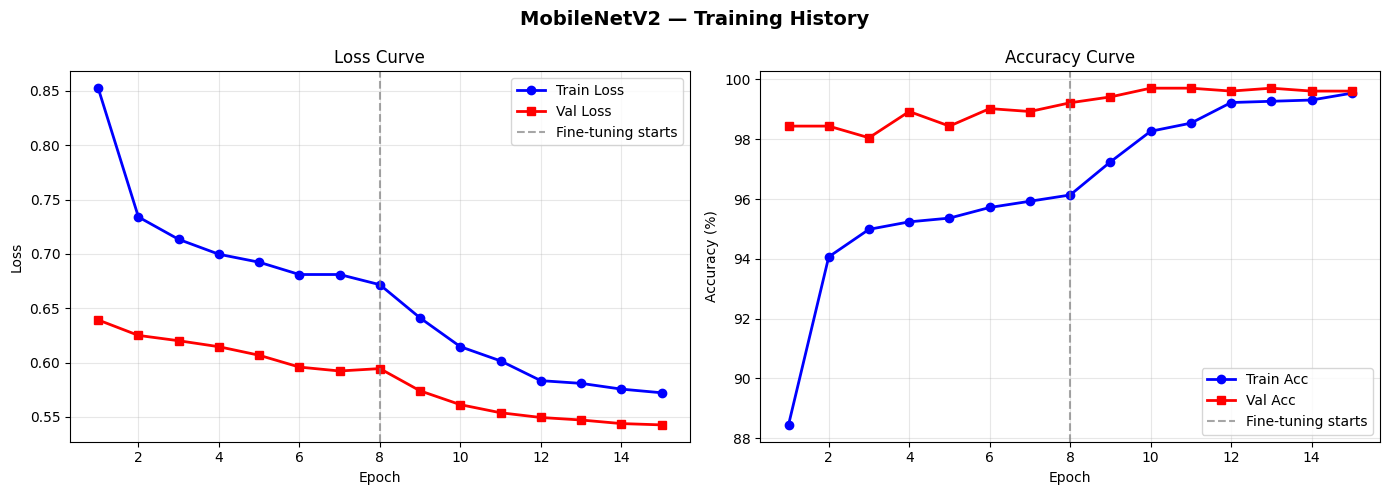

Training history plots saved.


In [13]:
#  Plot training curves
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2
epochs_range = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 — Training History', fontsize=14, fontweight='bold')

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   'r-s', label='Val Loss',   linewidth=2)
ax1.axvline(x=EPOCHS_PHASE1, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve'); ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', linewidth=2)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-s', label='Val Acc',   linewidth=2)
ax2.axvline(x=EPOCHS_PHASE1, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curve'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training history plots saved.')

## Cell 14 — Final Test Set Evaluation

In [14]:
# Collect all predictions on the test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

#  Metrics
test_acc  = accuracy_score(all_labels, all_preds)
test_prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_rec  = recall_score(all_labels, all_preds,    average='weighted', zero_division=0)
test_f1   = f1_score(all_labels, all_preds,        average='weighted', zero_division=0)

print('═' * 50)
print('       Test Set Evaluation Results')
print('═' * 50)
print(f'  Accuracy           : {test_acc*100:.2f}%')
print(f'  Weighted Precision : {test_prec*100:.2f}%')
print(f'  Weighted Recall    : {test_rec*100:.2f}%')
print(f'  Weighted F1-Score  : {test_f1*100:.2f}%')
print('═' * 50)

# Per-class report
short_class_names = [n.split('___')[-1][:25] for n in subset_class_names]
print('\nPer-class Classification Report:')
print(classification_report(all_labels, all_preds,
                             target_names=short_class_names,
                             zero_division=0))

══════════════════════════════════════════════════
       Test Set Evaluation Results
══════════════════════════════════════════════════
  Accuracy           : 99.51%
  Weighted Precision : 99.52%
  Weighted Recall    : 99.51%
  Weighted F1-Score  : 99.51%
══════════════════════════════════════════════════

Per-class Classification Report:
                           precision    recall  f1-score   support

               Apple_scab       0.98      1.00      0.99       104
                Black_rot       1.00      1.00      1.00        93
         Cedar_apple_rust       0.98      1.00      0.99        46
                  healthy       1.00      0.99      1.00       129
                  healthy       0.99      1.00      1.00       127
                  healthy       1.00      0.99      1.00       121
           Powdery_mildew       1.00      0.98      0.99       125
Cercospora_leaf_spot Gray       0.99      1.00      0.99        72
              Common_rust       1.00      0.99      1.

## Cell 15 — Confusion Matrix Heatmap

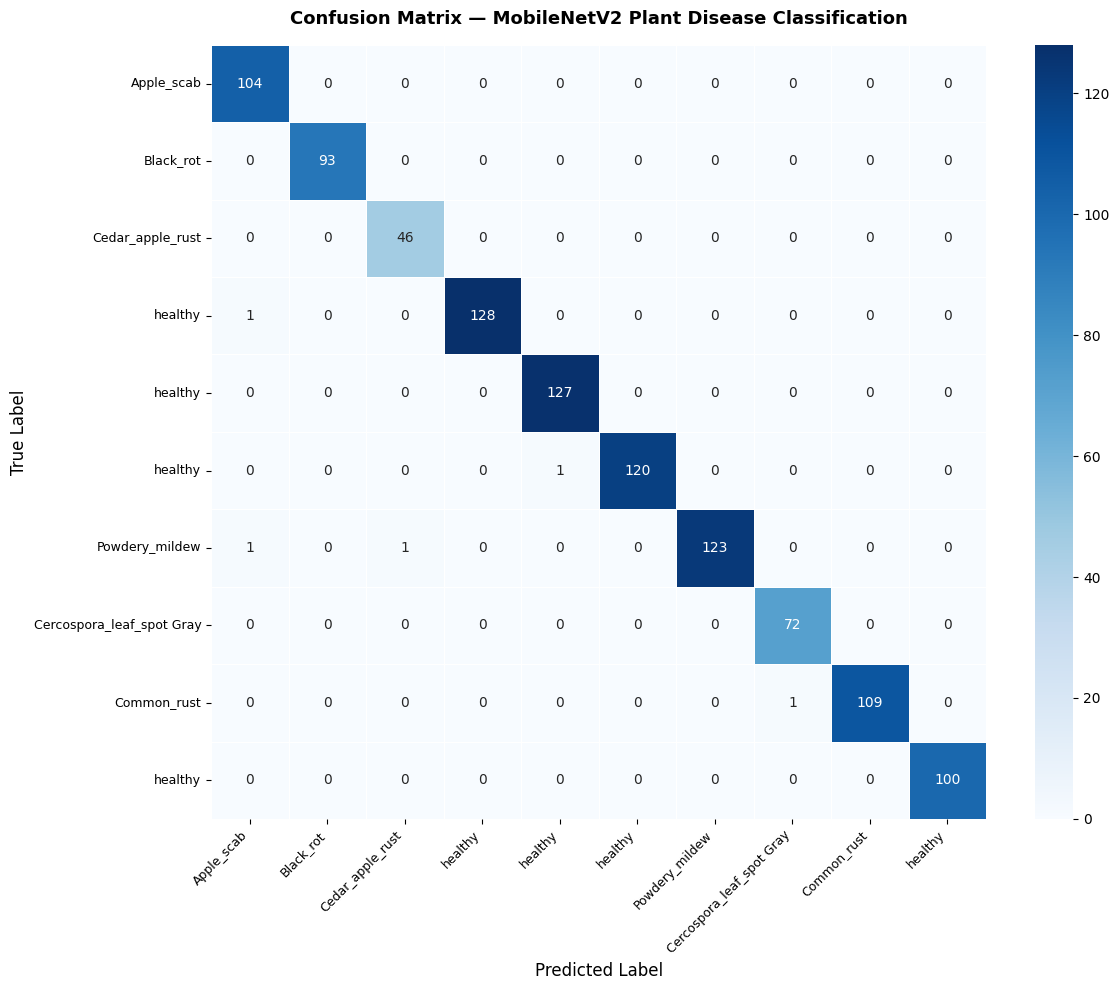

Confusion matrix saved.


In [15]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_class_names,
            yticklabels=short_class_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — MobileNetV2 Plant Disease Classification',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

## Cell 16 — Per-Class Accuracy Bar Chart

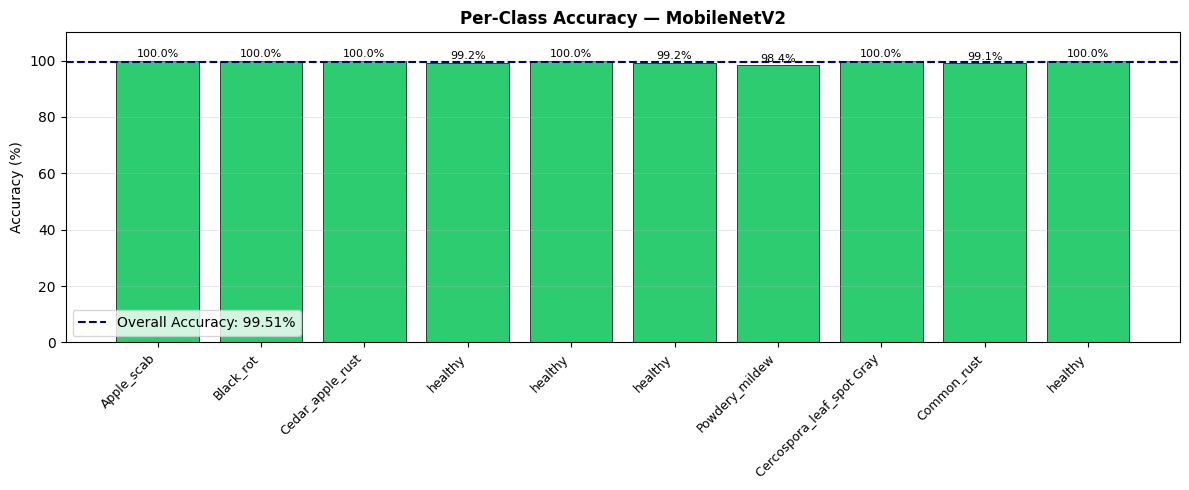

In [16]:
# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if a >= 0.80 else '#e67e22' if a >= 0.60 else '#e74c3c'
          for a in per_class_acc]
bars = ax.bar(range(SUBSET_CLASSES), per_class_acc * 100, color=colors,
              edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(SUBSET_CLASSES))
ax.set_xticklabels(short_class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy — MobileNetV2', fontweight='bold')
ax.set_ylim(0, 110)
ax.axhline(y=test_acc*100, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall Accuracy: {test_acc*100:.2f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 17 — Sample Predictions with Ground Truth

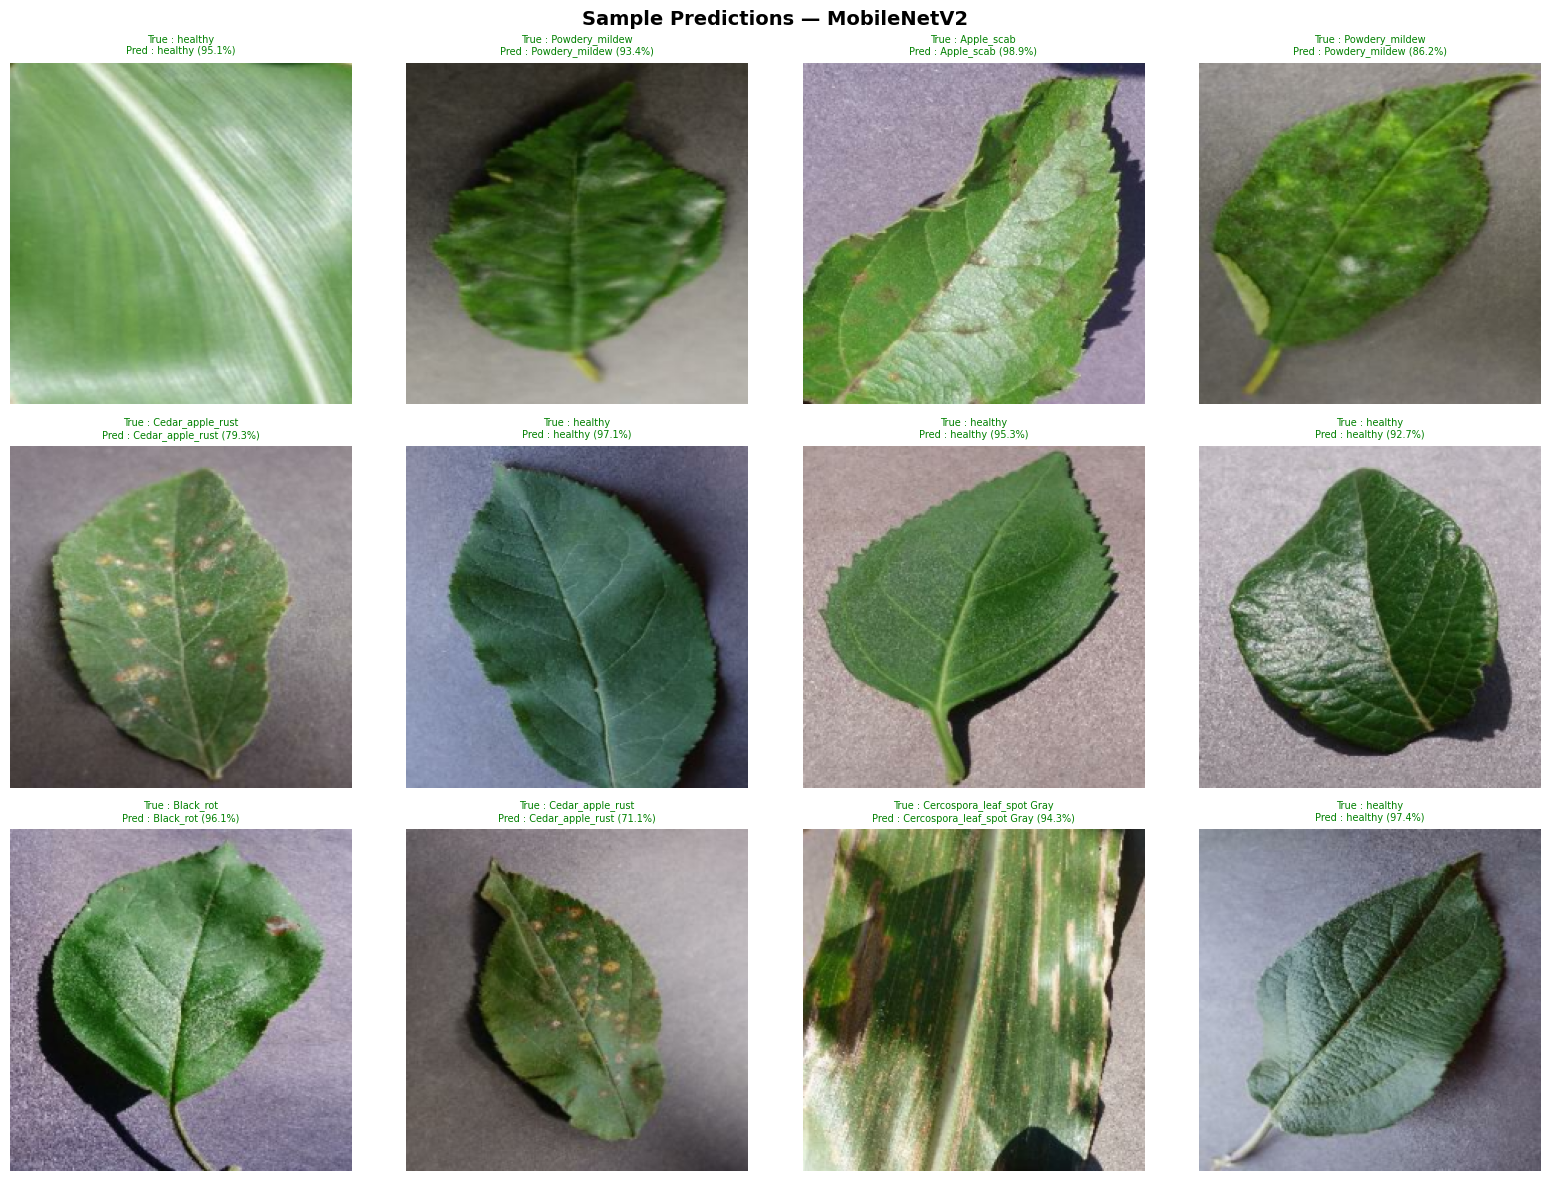

Sample predictions grid saved.


In [17]:
# Visualise predictions on random test images
import random

model.eval()
IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(3,1,1)
IMAGENET_STD_T  = torch.tensor(IMAGENET_STD).view(3,1,1)

sample_indices = random.sample(range(len(test_dataset)), 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Sample Predictions — MobileNetV2', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flatten(), sample_indices):
    img_tensor, true_label = test_dataset[idx]
    with torch.no_grad():
        out  = model(img_tensor.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(out, dim=1)
        pred = out.argmax(dim=1).item()
        conf = prob[0, pred].item()

    # Denormalise for display
    img_show = img_tensor * IMAGENET_STD_T + IMAGENET_MEAN_T
    img_show = img_show.permute(1, 2, 0).clamp(0, 1).numpy()

    ax.imshow(img_show)
    color = 'green' if pred == true_label else 'red'
    ax.set_title(
        f'True : {short_class_names[true_label]}\n'
        f'Pred : {short_class_names[pred]} ({conf*100:.1f}%)',
        color=color, fontsize=7
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample predictions grid saved.')

## Cell 18 — Final Summary & Parameter Report

In [18]:
# Final summary printout
# ⚠️  NOTE FOR REPORT: Copy EXACT numbers from this output into your report

total_params_final     = sum(p.numel() for p in model.parameters())
trainable_params_final = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=' * 60)
print('  FINAL SUMMARY — COPY THESE NUMBERS INTO YOUR REPORT')
print('=' * 60)
print(f'  Dataset          : PlantVillage (TensorFlow Datasets)')
print(f'  Dataset source   : https://www.tensorflow.org/datasets/catalog/plant_village')
print(f'  Classes used     : {SUBSET_CLASSES} (of 38 available)')
print(f'  Total images     : {len(images_list):,}')
print(f'  Train images     : {train_size:,}')
print(f'  Val images       : {val_size:,}')
print(f'  Test images      : {test_size:,}')
print(f'  Framework        : PyTorch {torch.__version__}')
print(f'  Model            : MobileNetV2 (ImageNet pretrained)')
print(f'  Input size       : 224 × 224 × 3')
print(f'  Total params     : {total_params_final:,}')
print(f'  Trainable params : {trainable_params_final:,}')
print(f'  Frozen params    : {total_params_final - trainable_params_final:,}')
print(f'  Training epochs  : {EPOCHS_PHASE1} (Phase 1) + {EPOCHS_PHASE2} (Phase 2) = {EPOCHS_PHASE1+EPOCHS_PHASE2} total')
print(f'  Batch size       : {BATCH_SIZE}')
print('-' * 60)
print(f'  Test Accuracy    : {test_acc*100:.2f}%')
print(f'  Precision        : {test_prec*100:.2f}%')
print(f'  Recall           : {test_rec*100:.2f}%')
print(f'  F1-Score         : {test_f1*100:.2f}%')
print('=' * 60)

  FINAL SUMMARY — COPY THESE NUMBERS INTO YOUR REPORT
  Dataset          : PlantVillage (TensorFlow Datasets)
  Dataset source   : https://www.tensorflow.org/datasets/catalog/plant_village
  Classes used     : 10 (of 38 available)
  Total images     : 6,839
  Train images     : 4,787
  Val images       : 1,025
  Test images      : 1,027
  Framework        : PyTorch 2.10.0+cu128
  Model            : MobileNetV2 (ImageNet pretrained)
  Input size       : 224 × 224 × 3
  Total params     : 2,885,898
  Trainable params : 2,343,370
  Frozen params    : 542,528
  Training epochs  : 8 (Phase 1) + 7 (Phase 2) = 15 total
  Batch size       : 32
------------------------------------------------------------
  Test Accuracy    : 99.51%
  Precision        : 99.52%
  Recall           : 99.51%
  F1-Score         : 99.51%
